In [3]:
# =========================
# 1. Import Library
# =========================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv('StudentPerformanceFactors.csv')

print("Data Awal:")
print(df.head())

Data Awal:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0    

In [5]:
# =========================
# 3. Cek Info Data
# =========================
print("\nInfo Dataset:")
print(df.info())


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 

In [6]:
# =========================
# 4. Handle Data Kategorikal (jika ada)
# =========================
df = pd.get_dummies(df)

In [7]:
# =========================
# 5. Ubah ke Klasifikasi
# =========================
df['Kategori'] = df['Exam_Score'].apply(lambda x: 1 if x >= 75 else 0)

In [8]:
# =========================
# 6. Pisah Fitur & Label
# =========================
X = df.drop(['Exam_Score', 'Kategori'], axis=1)
y = df['Kategori']

In [9]:
# =========================
# 7. Split Data
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# =========================
# 8. Scaling (WAJIB untuk SVM)
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# =========================
# 9. Model SVM
# =========================
svm_linear = SVC(kernel='linear', C=1)
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')

In [12]:
# =========================
# 10. Training
# =========================
svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

SVC(C=1)

In [13]:
# =========================
# 11. Prediksi
# =========================
pred_linear = svm_linear.predict(X_test)
pred_rbf = svm_rbf.predict(X_test)

In [15]:
print(classification_report(y_test, pred_linear, zero_division=0))
print(classification_report(y_test, pred_rbf, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1296
           1       0.00      0.00      0.00        26

    accuracy                           0.98      1322
   macro avg       0.49      0.50      0.50      1322
weighted avg       0.96      0.98      0.97      1322

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1296
           1       0.00      0.00      0.00        26

    accuracy                           0.98      1322
   macro avg       0.49      0.50      0.50      1322
weighted avg       0.96      0.98      0.97      1322



In [16]:
print(y.value_counts())

Kategori
0    6483
1     124
Name: count, dtype: int64


In [17]:
print(y.value_counts())

Kategori
0    6483
1     124
Name: count, dtype: int64


In [18]:
SVC(kernel='rbf', C=10, gamma=0.1, class_weight='balanced')

SVC(C=10, class_weight='balanced', gamma=0.1)

In [19]:
y.value_counts()

Kategori
0    6483
1     124
Name: count, dtype: int64

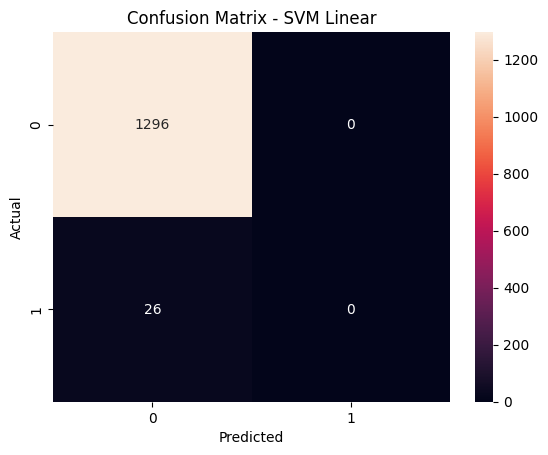

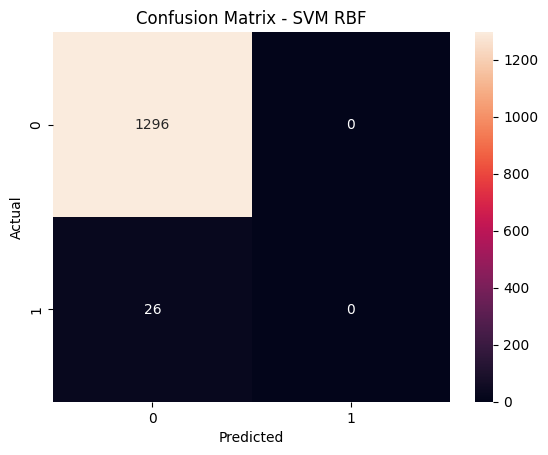

In [21]:
# =========================
# 13. Confusion Matrix (Visualisasi)
# =========================
cm_linear = confusion_matrix(y_test, pred_linear)
cm_rbf = confusion_matrix(y_test, pred_rbf)

plt.figure()
sns.heatmap(cm_linear, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM Linear")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure()
sns.heatmap(cm_rbf, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM RBF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# =========================
# 14. Eksperimen C & Gamma
# =========================
print("\n=== Eksperimen Parameter ===")

for C in [0.1, 1, 10]:
    for gamma in [0.01, 0.1, 1]:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        print(f"C={C}, gamma={gamma} -> Accuracy={acc:.3f}")


=== Eksperimen Parameter ===
C=0.1, gamma=0.01 -> Accuracy=0.980
C=0.1, gamma=0.1 -> Accuracy=0.980
C=0.1, gamma=1 -> Accuracy=0.980
C=1, gamma=0.01 -> Accuracy=0.980
C=1, gamma=0.1 -> Accuracy=0.980
C=1, gamma=1 -> Accuracy=0.980
C=10, gamma=0.01 -> Accuracy=0.983
C=10, gamma=0.1 -> Accuracy=0.980
C=10, gamma=1 -> Accuracy=0.980
